In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler

import arviz as az

/home/amaan/miniforge3/envs/stan/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# data = pd.read_csv('data/speed_dating_data.csv', sep=',', encoding='unicode_escape')
data = pd.read_csv('data/speed_dating_data.csv', sep=',', encoding='ISO-8859-1')
data.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='attr', ylabel='Count'>

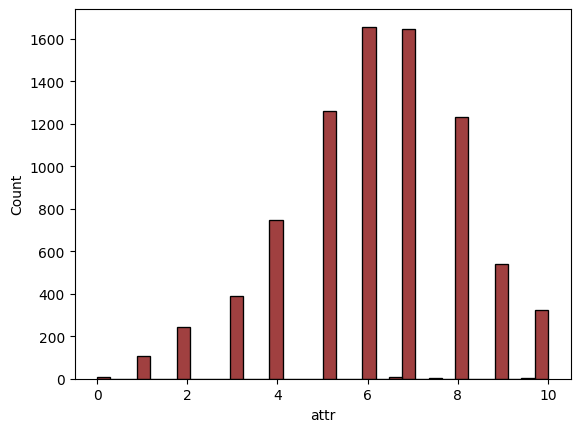

In [4]:
sns.histplot(data.attr, color='maroon', alpha=0.75)

In [5]:
data = data[['attr', 'sinc', 'shar', 'dec']].dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 8377
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   attr    7267 non-null   float64
 1   sinc    7267 non-null   float64
 2   shar    7267 non-null   float64
 3   dec     7267 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 283.9 KB


## Handy Function to Plot Predictions per Subject

In [6]:
scaler = StandardScaler()
cols = ['attr', 'sinc', 'shar']
data[cols] = scaler.fit_transform(data[cols])

<Axes: ylabel='Count'>

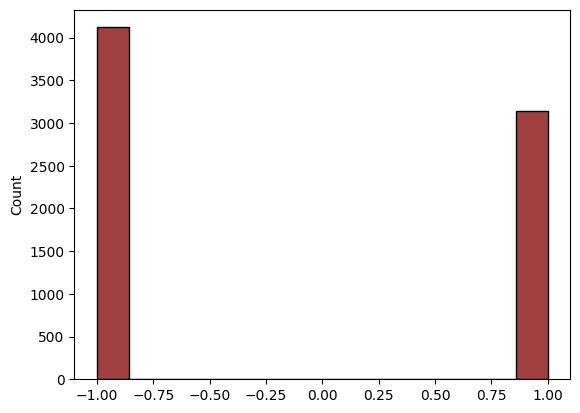

In [7]:
dec1 = np.float64(data.dec * 2 - 1)
sns.histplot(dec1, color='maroon', alpha=0.75)

In [8]:
# correlation
data[["attr", "sinc", "shar", "dec"]].corr()

,attr,sinc,shar,dec
attr,1.000000,0.401670,0.480331,0.485902
sinc,0.401670,1.000000,0.398321,0.208105
shar,0.480331,0.398321,1.000000,0.401667
dec,0.485902,0.208105,0.401667,1.000000


In [9]:
# Prepare data in Stan friendly format
data_dict = {
    'N': data.shape[0],
    'x1': data.attr,
    'x2': data.sinc,
    'x3': data.shar,
    'y': data.dec,
    'N_ex': 0,
    'x1_ex': [],
    'x1_ex': [],
    'x1_ex': [],
    'y_ex': [],
}

# Compile model
model = CmdStanModel(stan_file="models/hw4_model_new.stan")


# Sample (i.e., inverse inference)
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

19:09:17 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]



chain 1:   3%|▎         | 100/3500 [00:01<00:33, 100.12it/s, (Warmup)]

chain 1:   6%|▌         | 200/3500 [00:01<00:30, 108.78it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:02<00:23, 133.38it/s, (Warmup)]



chain 1:  11%|█▏        | 400/3500 [00:02<00:20, 151.12it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:03<00:17, 171.64it/s, (Warmup)]




chain 1:  17%|█▋        | 600/3500 [00:03<00:15, 183.39it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:04<00:14, 198.66it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:04<00:12, 209.57it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:05<00:11, 220.68it/s, (Warmup)]





chain 1:  29%|██▊       | 1000/3500 [00:05<00:11, 212.27it/s, (Sampling)]

chain 1:  31%|███▏      | 1100/3500 [00:06<00:15, 156.55it/s, (Sampling)]


chain 1:  34%|███▍      | 1200/3500 [00:07<00:18, 122.88it/s, (Sampling)]


chain 1:  40%|████      | 1400/3500 [00:10<00:20


19:09:59 - cmdstanpy - INFO - CmdStan done processing.


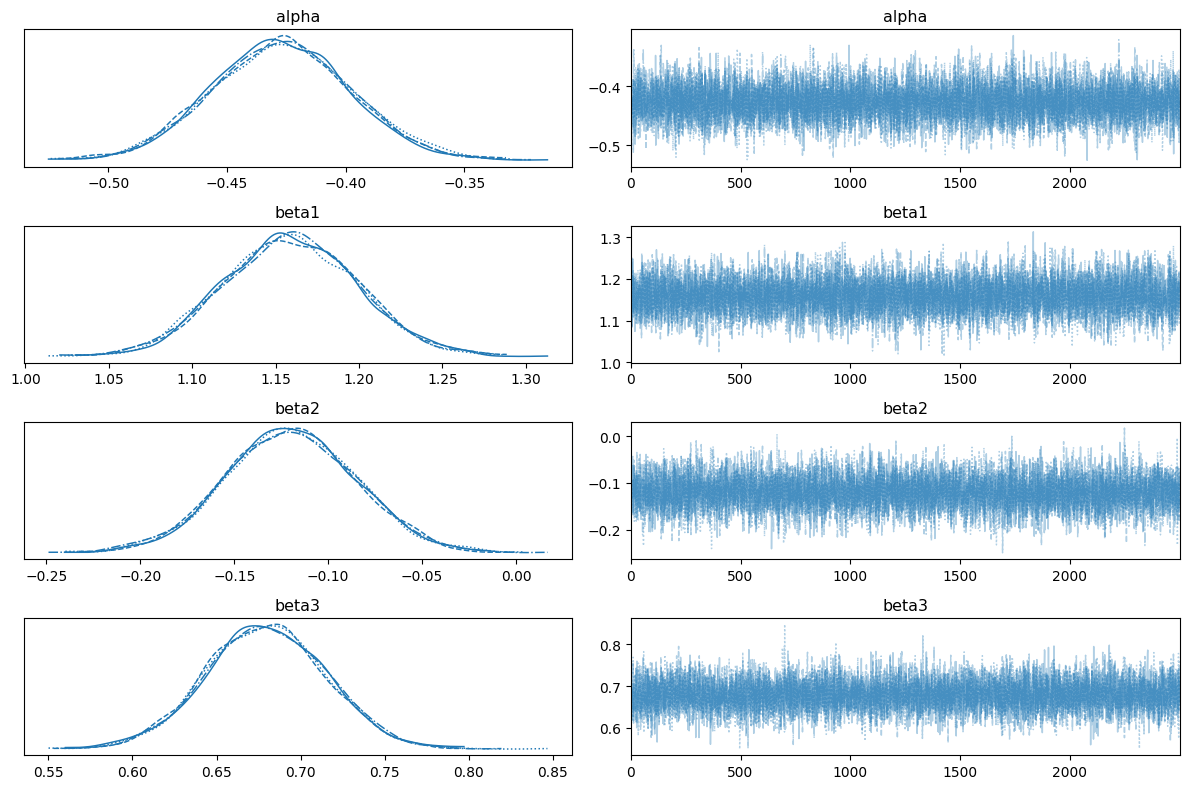

In [10]:
_ = az.plot_trace(fit, var_names=['alpha', 'beta1', 'beta2', 'beta3'])
plt.tight_layout()

In [1]:
results = fit.draws_pd()

NameError: name 'fit' is not defined

In [11]:
results.head()

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,preds[7258],preds[7259],preds[7260],preds[7261],preds[7262],preds[7263],preds[7264],preds[7265],preds[7266],preds[7267]
0,1.0,1.0,1.0,-3774.2039,0.612619,0.753858,2.0,3.0,0.0,3778.8978,...,-0.363673,-0.212064,-0.616456,-0.528386,-0.089700,-0.074421,-0.144208,-0.121382,-0.155846,-0.024521
1,1.0,2.0,2.0,-3774.2530,0.948161,0.753858,3.0,7.0,0.0,3774.8743,...,-0.357659,-0.202751,-0.623749,-0.518619,-0.083074,-0.071345,-0.141879,-0.113293,-0.150050,-0.022177
2,1.0,3.0,3.0,-3775.7465,0.751552,0.753858,2.0,7.0,0.0,3777.1415,...,-0.359279,-0.208179,-0.590484,-0.541764,-0.089953,-0.070787,-0.134042,-0.121453,-0.154771,-0.025017
3,1.0,4.0,4.0,-3776.5510,0.922436,0.753858,2.0,7.0,0.0,3778.6223,...,-0.363524,-0.210943,-0.661694,-0.501086,-0.083613,-0.076208,-0.156077,-0.114402,-0.151266,-0.021665
4,1.0,5.0,5.0,-3776.5115,0.926137,0.753858,2.0,3.0,0.0,3778.5126,...,-0.352734,-0.215680,-0.638323,-0.509958,-0.083980,-0.069200,-0.138473,-0.115058,-0.145704,-0.021462


<Axes: ylabel='Density'>

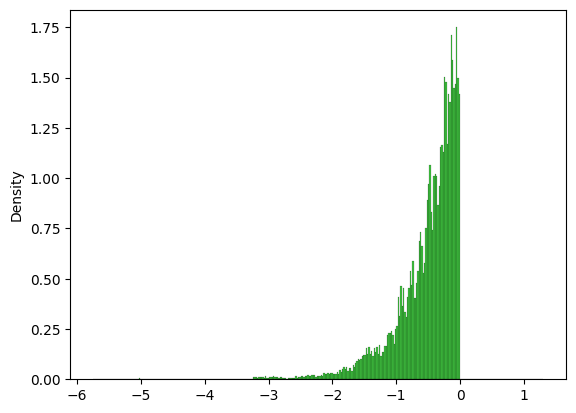

In [12]:
# Marginal check
# sns.histplot(data.shar, color='maroon', stat='density')
sns.histplot(results.iloc[:20, 10:].values.flatten(), stat='density', color='#00AA00')

In [16]:
dims = {"y": ["time"], "x1": ["time"], "preds": ["time"], "y_hat": ["time"]}
idata_kwargs = {
    "posterior_predictive": ["y_hat"],
    "log_likelihood": ["preds"],
    "dims": dims,
}
idata = az.from_cmdstanpy(
    posterior=fit, observed_data={"y": data.dec}, constant_data={"x": data.attr}, **idata_kwargs
)

ValueError: fit data, unknown variable: y_hat

In [13]:
az.summary(fit, var_names=['alpha', 'beta1', 'beta2', 'beta3'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.427,0.029,-0.479,-0.372,0.0,0.0,9135.0,8076.0,1.0
beta1,1.158,0.039,1.087,1.234,0.0,0.0,9372.0,7196.0,1.0
beta2,-0.121,0.034,-0.184,-0.055,0.0,0.0,9403.0,7644.0,1.0
beta3,0.679,0.035,0.615,0.745,0.0,0.0,9931.0,8098.0,1.0
